# Лабораторная работа №1
Дущенко Даниил Александрович, К3341. Все ячейки выполняются сверху вниз. Эмбеддинги работают на CPU; локальный путь можно задать AOT_EMBEDDING_PATH.

In [1]:
from pathlib import Path
import os,json,re
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from razdel import tokenize, sentenize
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer


HERE=Path.cwd() if Path.cwd().name=="lab01_representations" else Path.cwd()/"lab01_representations"


E:\AOT-work\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Данные, пропуски, дубликаты и поверхностные признаки

In [2]:
out=HERE/'results';out.mkdir(exist_ok=True)
df=pd.read_csv(HERE/'data/texts.csv')
audit={'n':len(df),'missing':df.isna().sum().to_dict(),'duplicate_texts':int(df.text.duplicated().sum()),'class_counts':df.label.value_counts().to_dict()}
features=pd.DataFrame({'id':df.id,'characters':df.text.str.len(),'tokens':df.text.map(lambda t:len(list(tokenize(t)))),'sentences':df.text.map(lambda t:len(list(sentenize(t)))),'exclamations':df.text.str.count('!'),'questions':df.text.str.count(r'\?'),'uppercase_ratio':df.text.map(lambda t:sum(c.isupper() for c in t)/max(1,sum(c.isalpha() for c in t)))})
features.to_csv(out/'surface_features.csv',index=False); audit['lengths']=features[['characters','tokens']].describe().to_dict()
(out/'audit.json').write_text(json.dumps(audit,ensure_ascii=False,indent=2),encoding='utf-8')


616

## 2. Девять контролируемых преобразований

In [3]:
transformations=[
  ('random_00470','reorder','Обожаю её))) Спокойная хорошая песенка)))',False,'Переставлены предложения, положительная оценка сохранена.'),
  ('random_00470','paraphrase','Мне очень нравится эта приятная спокойная песня.',False,'Выражено то же восхищение спокойной песней другими словами.'),
  ('random_00470','meaning_change','Спокойная хорошая песенка))) Не обожаю её)))',True,'Отрицание меняет отношение автора: восхищение больше не утверждается.'),
  ('random_20278','reorder','У тебя в последнее время одни глупые репосты.',False,'Перемещение обстоятельства не меняет отрицательную оценку репостов.'),
  ('random_20278','paraphrase','Последние перепубликации на твоей странице все бестолковые.',False,'Сохраняются адресат, временная область и отрицательное отношение.'),
  ('random_20278','meaning_change','В последнее время у тебя не одни глупые репосты.',True,'Отрицается всеобщность: теперь допускаются и неглупые публикации.'),
  ('random_05842','reorder','Роднуля, когда выезжаешь?))))))',False,'Обращение перенесено, вопрос о времени выезда сохранён.'),
  ('random_05842','paraphrase','Когда отправляешься, дорогой человек?',False,'Переформулирован вопрос о времени отправления; оттенок обращения ослаблен.'),
  ('random_05842','meaning_change','Когда приезжаешь, роднуля?))))))',True,'Вместо времени выезда спрашивается время прибытия.'),
]


## 3. Сохранение исходных и изменённых текстов

In [4]:
rows=[]
for ident,kind,text,changed,reason in transformations:
    source=df.set_index('id').loc[ident]
    rows.append(dict(id=ident,label=source.label,original=source.text,transformation=kind,transformed=text,meaning_changed=changed,judgment=reason,reviewer='Codex analytical judgment, not human participant'))
pairs=pd.DataFrame(rows); pairs.to_csv(HERE/'data/transformations.csv',index=False)


## 4. Bag-of-words и TF–IDF

In [5]:
tok=lambda text:[t.text.lower() for t in tokenize(text) if any(c.isalnum() for c in t.text)]
bow=CountVectorizer(tokenizer=tok,token_pattern=None,lowercase=False)
tfidf=TfidfVectorizer(tokenizer=tok,token_pattern=None,lowercase=False)
for name,vectorizer in [('bow',bow),('tfidf',tfidf)]:
    matrix=vectorizer.fit_transform(df.text)
    np.savez_compressed(out/f'{name}_matrix.npz',data=matrix.data,indices=matrix.indices,indptr=matrix.indptr,shape=matrix.shape)
    (out/f'{name}_vocabulary.json').write_text(json.dumps(vectorizer.get_feature_names_out().tolist(),ensure_ascii=False),encoding='utf-8')
    original=vectorizer.transform(pairs.original); altered=vectorizer.transform(pairs.transformed)
    pairs[name]=[float(cosine_similarity(original[i],altered[i])[0,0]) for i in range(9)]
    pairs[f'{name}_oov_ratio']=pairs.transformed.map(lambda s:sum(t not in vectorizer.vocabulary_ for t in tok(s))/max(1,len(tok(s))))


## 5. Sentence embeddings (CPU)

In [6]:
local=Path(os.getenv('AOT_EMBEDDING_PATH','E:/AI/models/embeddings/multilingual-e5-small'))
source=str(local) if local.exists() else 'intfloat/multilingual-e5-small'
model=SentenceTransformer(source,device='cpu')
embeddings=model.encode(['query: '+t for t in df.text],normalize_embeddings=True,batch_size=16,show_progress_bar=False)
np.save(out/'embeddings.npy',embeddings)
em=model.encode(['query: '+t for t in pairs.original]+['query: '+t for t in pairs.transformed],normalize_embeddings=True,batch_size=16,show_progress_bar=False)
pairs['embeddings']=(em[:9]*em[9:]).sum(axis=1)
pairs.to_csv(out/'similarities.csv',index=False)
(out/'embedding_config.json').write_text(json.dumps({'model':'intfloat/multilingual-e5-small','device':'cpu','prefix':'query: for both sides (symmetric similarity)','normalize_embeddings':True,'max_seq_length':model.max_seq_length,'dimensions':int(embeddings.shape[1])},indent=2))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7497.90it/s]

204

## 6. Распределение длин

In [7]:
sns.set_theme(style='whitegrid',font='DejaVu Sans')
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].hist(features.characters,bins=20,color='#436B93');axes[0].set(xlabel='Символы',ylabel='Число текстов',title='Длина текста в символах')
axes[1].hist(features.tokens,bins=20,color='#58836B');axes[1].set(xlabel='Токены razdel',ylabel='Число текстов',title='Длина текста в токенах')
fig.tight_layout();fig.savefig(out/'length_distribution.png',dpi=180);plt.close(fig)


## 7. Визуализация и сравнения

In [8]:
fig,ax=plt.subplots(figsize=(8,5))
labels=[f"{r.label}: {dict(reorder='перестановка',paraphrase='парафраз',meaning_change='изменение смысла')[r.transformation]}" for r in pairs.itertuples()]
sns.heatmap(pairs[['bow','tfidf','embeddings']],annot=True,fmt='.3f',vmin=0,vmax=1,cmap='YlGnBu',yticklabels=labels,ax=ax)
ax.set(xlabel='Представление',ylabel='');fig.tight_layout();fig.savefig(out/'similarity_heatmap.png',dpi=180);plt.close(fig)
print(pairs[['label','transformation','meaning_changed','bow','tfidf','embeddings']].to_string(index=False))
display(pairs)


   label transformation  meaning_changed      bow    tfidf  embeddings
positive        reorder            False 1.000000 1.000000    0.990332
positive     paraphrase            False 0.223607 0.247325    0.929906
positive meaning_change             True 0.912871 0.974124    0.974273
negative        reorder            False 1.000000 1.000000    0.999329
negative     paraphrase            False 0.000000 0.000000    0.903911
negative meaning_change             True 0.942809 0.979176    0.986846
 neutral        reorder            False 1.000000 1.000000    0.990166
 neutral     paraphrase            False 0.577350 0.505209    0.891779
 neutral meaning_change             True 0.816497 0.792224    0.987879


,id,label,original,transformation,transformed,meaning_changed,judgment,reviewer,bow,bow_oov_ratio,tfidf,tfidf_oov_ratio,embeddings
0,random_00470,positive,Спокойная хорошая песенка))) Обожаю её))),reorder,Обожаю её))) Спокойная хорошая песенка))),False,"Переставлены предложения, положительная оценка...","Codex analytical judgment, not human participant",1.000000,0.000000,1.000000,0.000000,0.990332
1,random_00470,positive,Спокойная хорошая песенка))) Обожаю её))),paraphrase,Мне очень нравится эта приятная спокойная песня.,False,Выражено то же восхищение спокойной песней дру...,"Codex analytical judgment, not human participant",0.223607,0.428571,0.247325,0.428571,0.929906
2,random_00470,positive,Спокойная хорошая песенка))) Обожаю её))),meaning_change,Спокойная хорошая песенка))) Не обожаю её))),True,Отрицание меняет отношение автора: восхищение ...,"Codex analytical judgment, not human participant",0.912871,0.000000,0.974124,0.000000,0.974273
3,random_20278,negative,В последнее время у тебя одни глупые репосты.,reorder,У тебя в последнее время одни глупые репосты.,False,Перемещение обстоятельства не меняет отрицател...,"Codex analytical judgment, not human participant",1.000000,0.000000,1.000000,0.000000,0.999329
4,random_20278,negative,В последнее время у тебя одни глупые репосты.,paraphrase,Последние перепубликации на твоей странице все...,False,"Сохраняются адресат, временная область и отриц...","Codex analytical judgment, not human participant",0.000000,0.428571,0.000000,0.428571,0.903911
5,random_20278,negative,В последнее время у тебя одни глупые репосты.,meaning_change,В последнее время у тебя не одни глупые репосты.,True,Отрицается всеобщность: теперь допускаются и н...,"Codex analytical judgment, not human participant",0.942809,0.000000,0.979176,0.000000,0.986846
6,random_05842,neutral,"Когда выезжаешь, роднуля?))))))",reorder,"Роднуля, когда выезжаешь?))))))",False,"Обращение перенесено, вопрос о времени выезда ...","Codex analytical judgment, not human participant",1.000000,0.000000,1.000000,0.000000,0.990166
7,random_05842,neutral,"Когда выезжаешь, роднуля?))))))",paraphrase,"Когда отправляешься, дорогой человек?",False,Переформулирован вопрос о времени отправления;...,"Codex analytical judgment, not human participant",0.577350,0.750000,0.505209,0.750000,0.891779
8,random_05842,neutral,"Когда выезжаешь, роднуля?))))))",meaning_change,"Когда приезжаешь, роднуля?))))))",True,Вместо времени выезда спрашивается время прибы...,"Codex analytical judgment, not human participant",0.816497,0.333333,0.792224,0.333333,0.987879


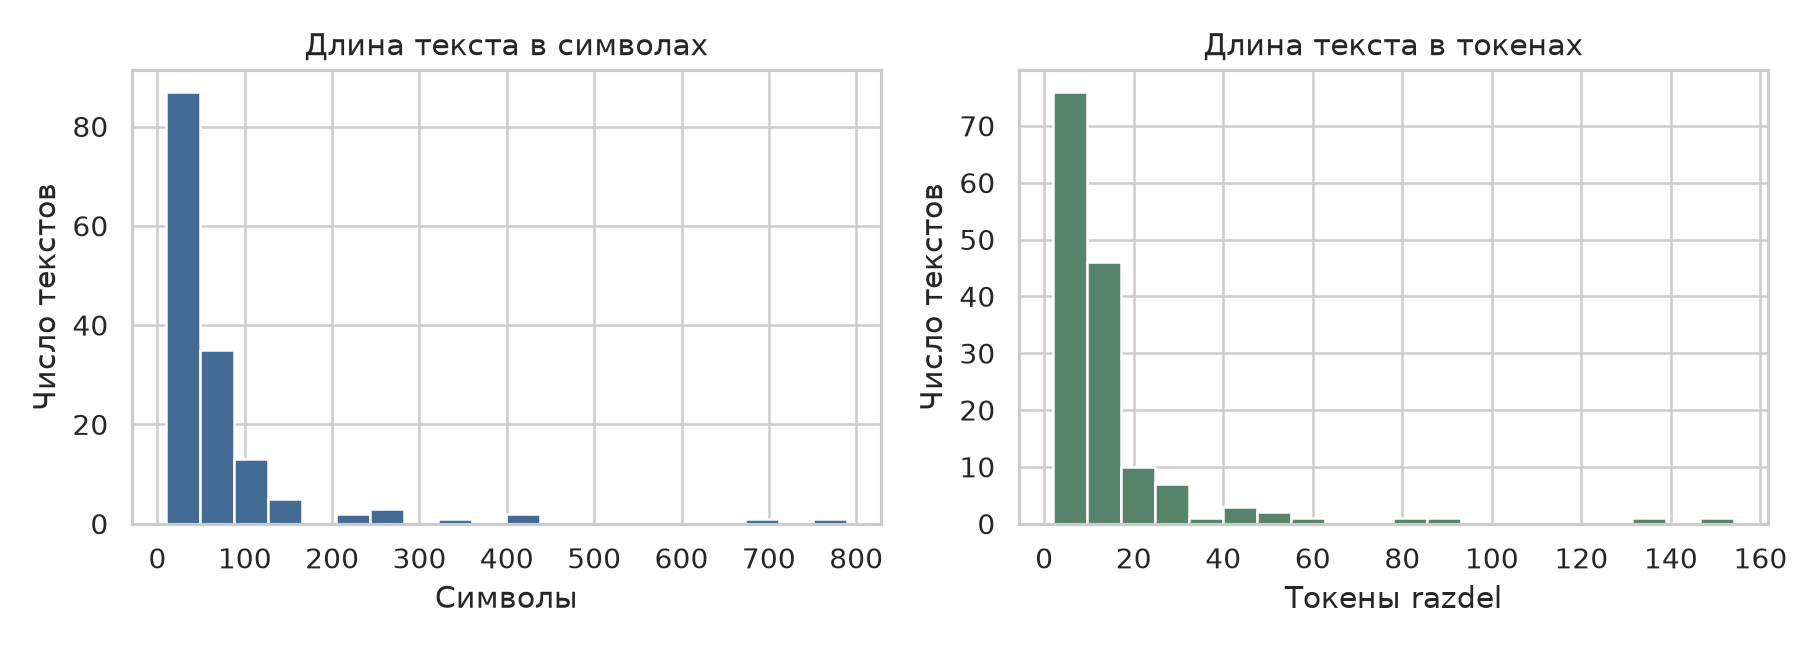

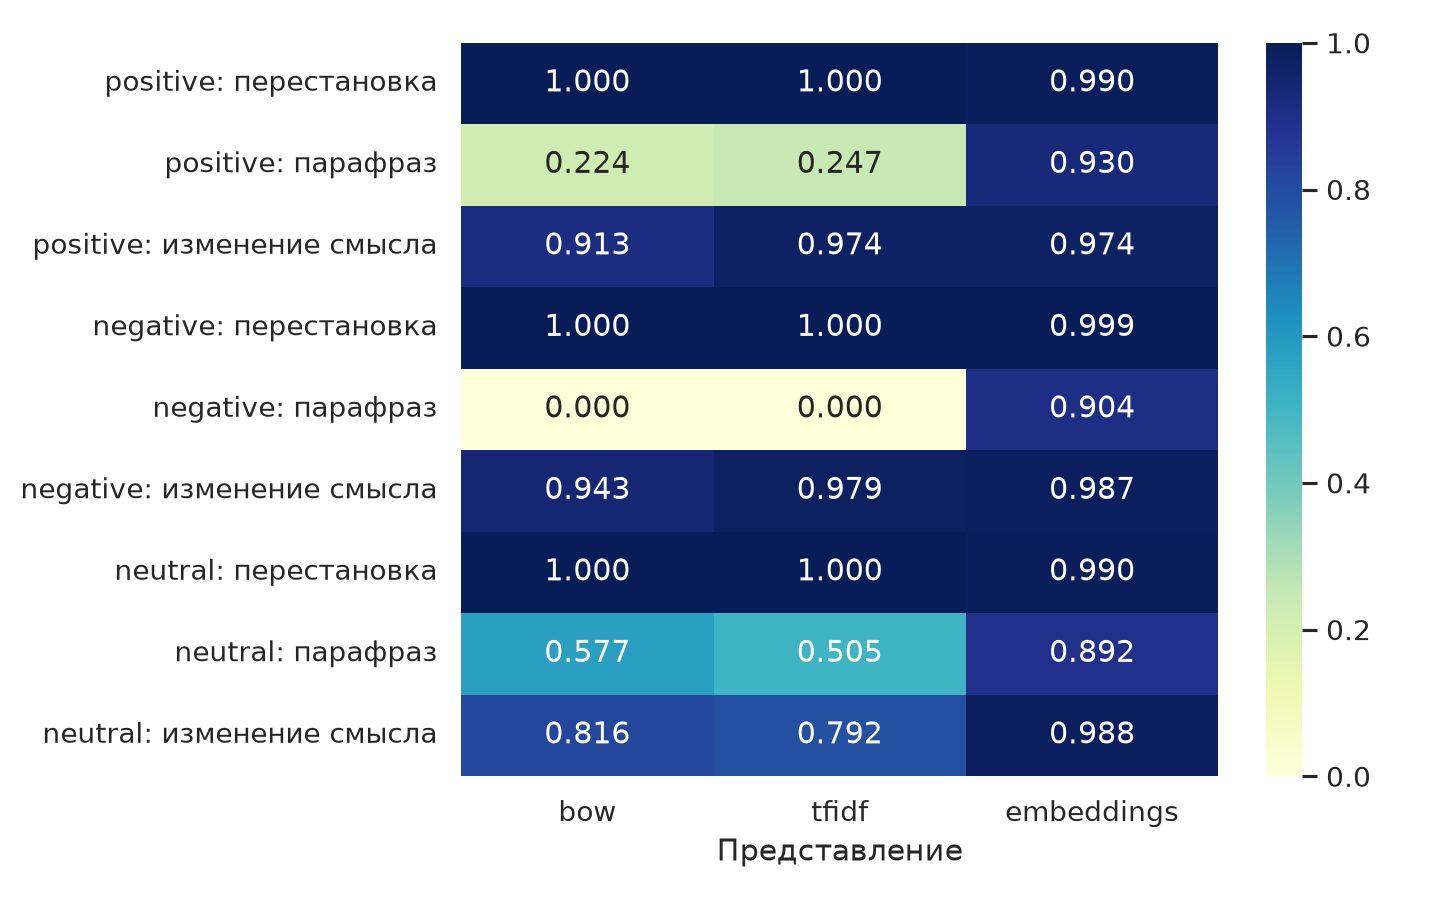

In [9]:
from IPython.display import Image, display
display(Image(filename=str(HERE/'results/length_distribution.png')))
display(Image(filename=str(HERE/'results/similarity_heatmap.png')))